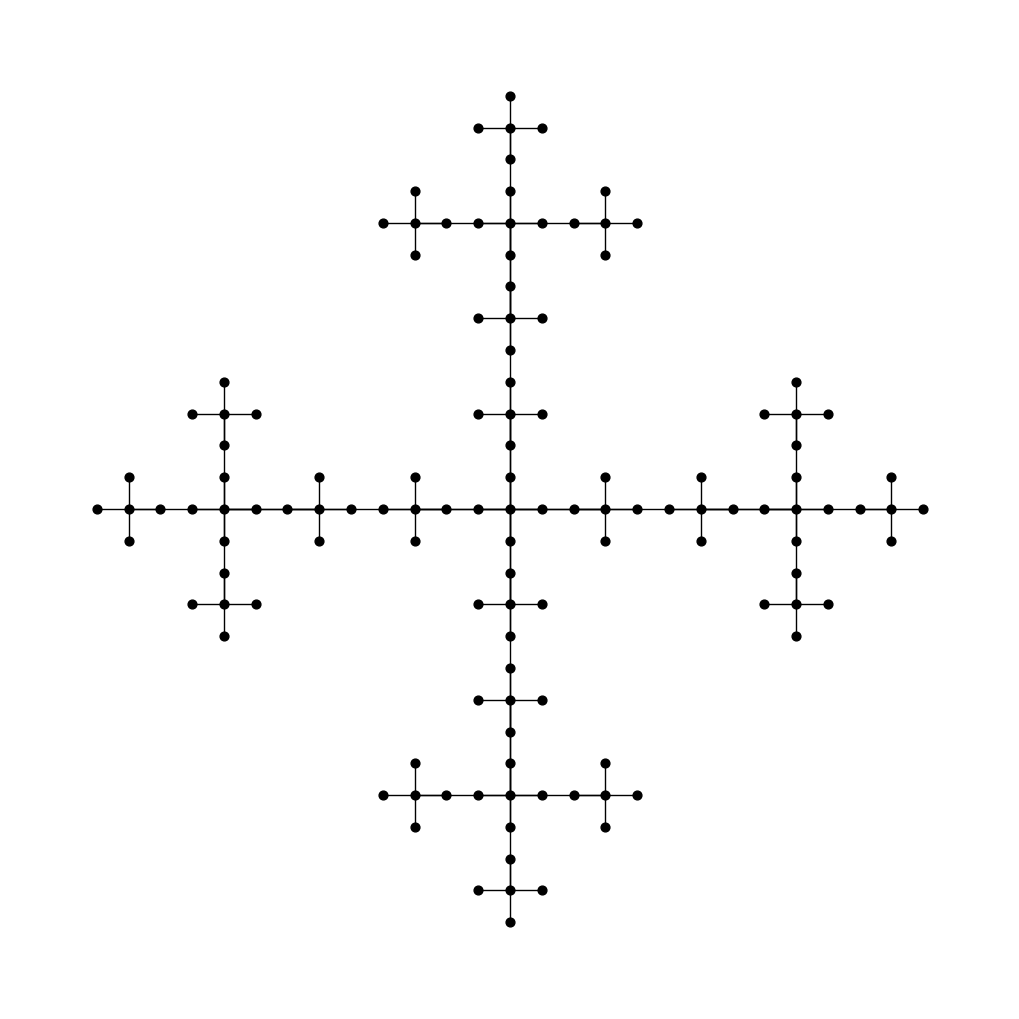

Vertices: 125
Edges: 124


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def build_vicsek(G, center, length, depth):
    if depth == 0 or length == 0:
        return

    # Only create nodes in the four directions (excluding the center)
    directions = [(0, 1), (0, -1), (1, 0), (-1, 0)]

    for dx, dy in directions:
        new_node = (center[0] + dx * length, center[1] + dy * length)

        # Add the new node and edge
        if new_node not in G:
            G.add_node(new_node)
        G.add_edge(center, new_node)

        # Recurse for the new node
        build_vicsek(G, new_node, length // 3, depth - 1)

    # Also recurse for the center point but with reduced parameters
    build_vicsek(G, center, length // 3, depth - 1)

# Create graph
G = nx.Graph()
center = (0, 0)
G.add_node(center)

build_vicsek(G, center, 27, 3)

# Draw
pos = {node: node for node in G.nodes()}
plt.figure(figsize=(10, 10))
nx.draw(G, pos, node_size=40, with_labels=False, node_color='black')
plt.axis("equal")
plt.show()

print("Vertices:", len(G.nodes()))
print("Edges:", len(G.edges()))

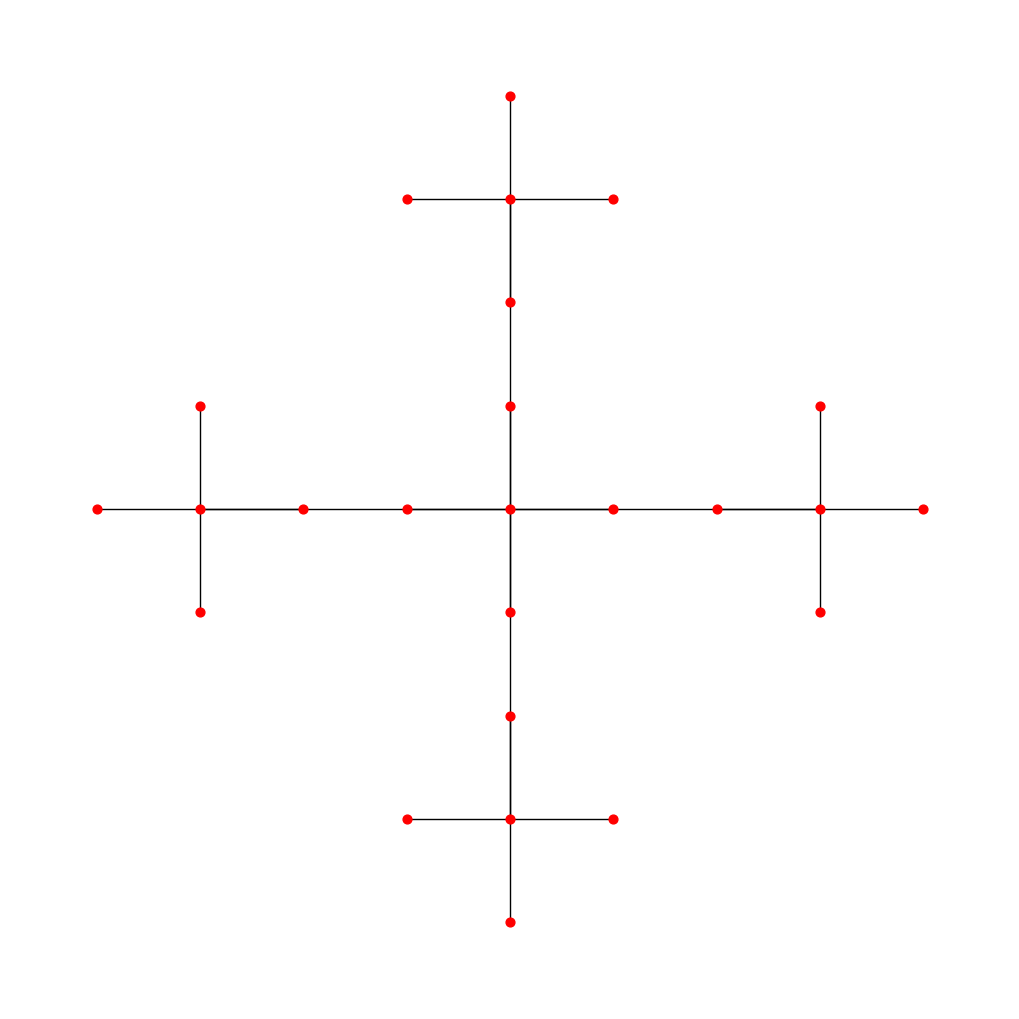

Vertices: 25
Edges: 24


In [1]:
import networkx as nx
import matplotlib.pyplot as plt

def build_vicsek(G, center, length, depth):
    if depth == 0 or length == 0:
        return

    # Only create nodes in the four directions (excluding the center)
    directions = [(0, 1), (0, -1), (1, 0), (-1, 0)]

    for dx, dy in directions:
        new_node = (center[0] + dx * length, center[1] + dy * length)

        # Add the new node and edge
        if new_node not in G:
            G.add_node(new_node)
        G.add_edge(center, new_node)

        # Recurse for the new node
        build_vicsek(G, new_node, length // 3, depth - 1)

    # Also recurse for the center point but with reduced parameters
    build_vicsek(G, center, length // 3, depth - 1)

# Create graph
G = nx.Graph()
center = (0, 0)
G.add_node(center)

build_vicsek(G, center, 27, 2)

# Draw
pos = {node: node for node in G.nodes()}
plt.figure(figsize=(10, 10))
nx.draw(G, pos, node_size=40, with_labels=False, node_color='red')
plt.axis("equal")
plt.show()

print("Vertices:", len(G.nodes()))
print("Edges:", len(G.edges()))

In [ ]:
!pip install ortools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.7/27.7 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.1/321.1 kB 21.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.31.1 which is incompatible.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 6.31.1 which is incompatibl

Graceful labeling found:
{(0, 0): 22, (0, 9): 0, (0, 12): 1, (0, 6): 21, (3, 9): 24, (-3, 9): 23, (0, -9): 5, (0, -6): 15, (0, -12): 12, (3, -9): 13, (-3, -9): 14, (9, 0): 2, (9, 3): 4, (9, -3): 16, (12, 0): 8, (6, 0): 20, (-9, 0): 3, (-9, 3): 18, (-9, -3): 19, (-6, 0): 6, (-12, 0): 7, (0, 3): 10, (0, -3): 17, (3, 0): 9, (-3, 0): 11}


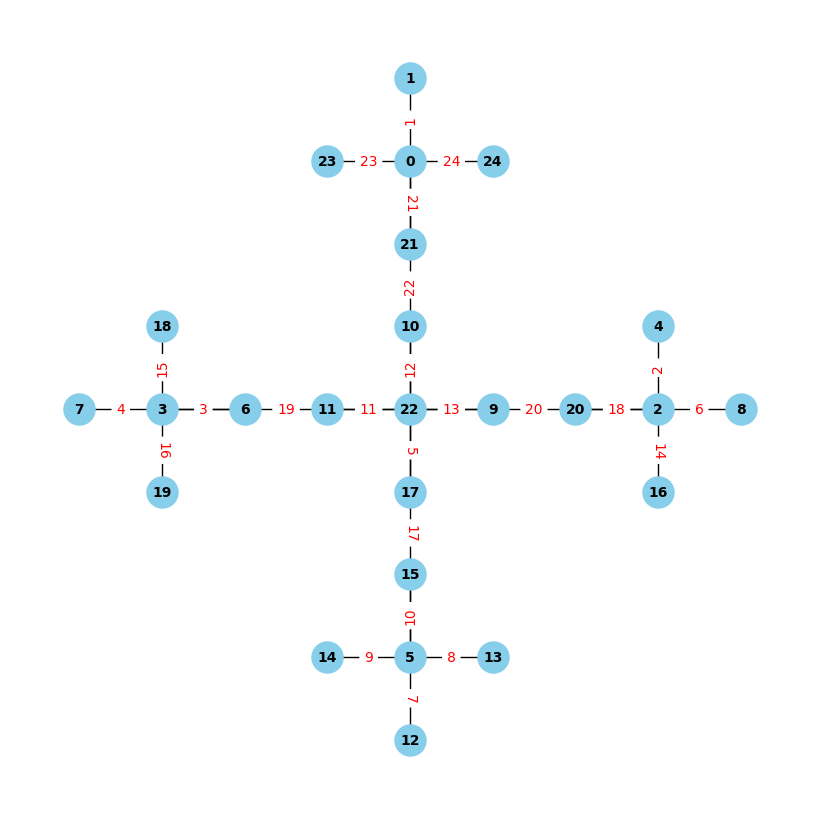

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from ortools.sat.python import cp_model

# ---------------- Graceful Labeling ----------------
def graceful_labeling(G):
    n = len(G.nodes())
    m = len(G.edges())
    model = cp_model.CpModel()

    # Variables: one integer per vertex
    labels = {v: model.NewIntVar(0, m, f"label_{v}") for v in G.nodes()}

    # All vertex labels must be distinct
    model.AddAllDifferent(labels.values())

    # Edge labels: absolute differences
    edge_labels = []
    for i, (u, v) in enumerate(G.edges()):
        diff = model.NewIntVar(1, m, f"edge_{i}")
        model.AddAbsEquality(diff, labels[u] - labels[v])
        edge_labels.append(diff)

    # Edge labels must be distinct
    model.AddAllDifferent(edge_labels)

    # Edge labels must cover {1,...,m} → enforce via sum constraint
    model.Add(sum(edge_labels) == m * (m + 1) // 2)

    # Solve
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 20
    status = solver.Solve(model)

    if status in [cp_model.OPTIMAL, cp_model.FEASIBLE]:
        return {v: solver.Value(labels[v]) for v in G.nodes()}
    else:
        return None

# ---------------- Build Vicsek Fractal ----------------
def build_vicsek(G, center, length, depth):
    if depth == 0 or length == 0:
        return
    directions = [(0, 1), (0, -1), (1, 0), (-1, 0)]
    for dx, dy in directions:
        new_node = (center[0] + dx * length, center[1] + dy * length)
        if new_node not in G:
            G.add_node(new_node)
        G.add_edge(center, new_node)
        build_vicsek(G, new_node, length // 3, depth - 1)
    build_vicsek(G, center, length // 3, depth - 1)

# ---------------- Main ----------------
G = nx.Graph()
center = (0, 0)
G.add_node(center)
build_vicsek(G, center, 9, 2)   # change depth here

labels = graceful_labeling(G)

if labels:
    print("Graceful labeling found:")
    print(labels)

    # Draw nodes with graceful labels
    pos = {node: node for node in G.nodes()}  # use coordinates
    plt.figure(figsize=(8, 8))
    nx.draw(
        G, pos,
        node_size=500,
        node_color="skyblue",
        with_labels=True,
        labels={node: labels[node] for node in G.nodes()},
        font_size=10,
        font_weight="bold"
    )

    # Draw edge labels (absolute differences)
    edge_labels = {(u, v): abs(labels[u] - labels[v]) for u, v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color="red")

    plt.axis("equal")
    plt.show()

else:
    print("No graceful labeling found.")
